<a href="https://colab.research.google.com/github/Raghv-github/Raghv-github/blob/main/AQI_Prediction_of_india.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AQI prediction for the different cities of india**

Air pollution has become one of the most pressing environmental challenges in India, with major cities experiencing hazardous levels of pollutants such as **PM2.5, PM10, NO₂, and SO₂**. Monitoring and forecasting the Air Quality Index (AQI) is essential for understanding pollution trends, formulating policies, and alerting citizens to potential health risks.

In this project, we built a **machine learning-based AQI prediction model using historical air quality data from various Indian cities**. The dataset includes key pollutants such as PM2.5, PM10, NO₂, CO, SO₂, O₃, NH₃, and others, along with city-level attributes.

We applied and compared several regression algorithms — including **XGBoost, Random Forest, Gradient Boosting, AdaBoost, CatBoost, and LightGBM **— to predict AQI values based on these pollutant concentrations. After evaluating multiple models using performance metrics such as R², RMSE, and MAE, XGBoost emerged as the best-performing algorithm due to its robustness, speed, and high predictive accuracy.

In [2]:
import numpy as np
import pandas as pd

In [33]:
!pip install kagglehub

In [47]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.
Path to dataset files: /kaggle/input/air-quality-data-in-india


In [48]:
import os
df = pd.read_csv(os.path.join(path, 'city_day.csv'))

In [49]:
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [50]:
df['City'].value_counts()

,count
City,
Ahmedabad,2009
Bengaluru,2009
Chennai,2009
Mumbai,2009
Lucknow,2009
Delhi,2009
Hyderabad,2006
Patna,1858
Gurugram,1679


In [51]:
df.isnull().mean()*100

,0
City,0.000000
Date,0.000000
PM2.5,15.570079
PM10,37.723071
NO,12.129626
NO2,12.139785
NOx,14.171549
NH3,34.973418
CO,6.972334
SO2,13.050692


In [52]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

# **Data Cleaning preparation**

Data Inspection
↓
Remove Irrelevant Columns
↓
Remove Duplicates
↓
Missing Data Analysis
↓
Termination (Drop High Missing)
↓
Fix Data Types
↓
Handle Invalid Values
↓
Outlier Treatment
↓
Imputation
↓
Encoding
↓
Transformation
↓
Scaling
↓
Feature Selection
↓
Train-Test Split
↓
Modeling


1.Droping Unessary columns and whose missing value is greater than 40

In [61]:
df.drop_duplicates(inplace=True)

In [53]:
df.drop(columns=['Date','Xylene'],inplace=True)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   PM2.5       24933 non-null  float64
 2   PM10        18391 non-null  float64
 3   NO          25949 non-null  float64
 4   NO2         25946 non-null  float64
 5   NOx         25346 non-null  float64
 6   NH3         19203 non-null  float64
 7   CO          27472 non-null  float64
 8   SO2         25677 non-null  float64
 9   O3          25509 non-null  float64
 10  Benzene     23908 non-null  float64
 11  Toluene     21490 non-null  float64
 12  AQI         24850 non-null  float64
 13  AQI_Bucket  24850 non-null  object 
dtypes: float64(12), object(2)
memory usage: 3.2+ MB


In [55]:
cols_num = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','AQI']
df[cols_num] = df[cols_num].fillna(method='bfill')

df['AQI_Bucket'] = df['AQI_Bucket'].fillna("Unknown")

/tmp/ipython-input-3881065661.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[cols_num] = df[cols_num].fillna(method='bfill')


/tmp/ipython-input-801004869.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AQI_Bucket'].fillna("Unknown",inplace=True)


In [56]:
df.isnull().mean()*100

,0
City,0.000000
PM2.5,0.000000
PM10,0.000000
NO,0.000000
NO2,0.000000
NOx,0.000000
NH3,0.000000
CO,0.000000
SO2,0.000000
O3,0.000000


In [57]:
df[['Benzene','Toluene']]=df[['Benzene','Toluene']].fillna(df[['Benzene','Toluene']].mean())

In [58]:
df.isnull().mean()*100

,0
City,0.0
PM2.5,0.0
PM10,0.0
NO,0.0
NO2,0.0
NOx,0.0
NH3,0.0
CO,0.0
SO2,0.0
O3,0.0


Now the variables, null values are handled and replaced.

# **2.Outliers Detections**

In [64]:
cols_nom=df['City']
col_or=df['AQI_Bucket']

<Axes: >

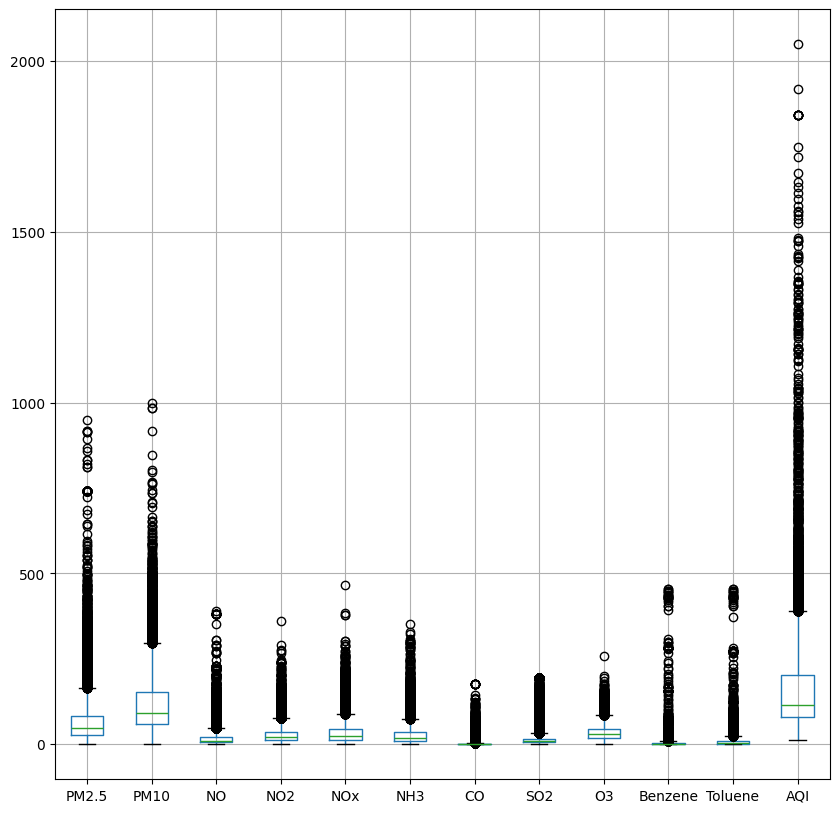

In [62]:
df.boxplot(figsize=(10,10))

Needs the removal of the extereme values

Z_cal method

In [65]:
from scipy import stats
import numpy as np
num_df=df.select_dtypes(include="number")
z_scores=np.abs(stats.zscore(num_df))
mask = (z_scores < 3).all(axis=1)
df_final = df.loc[mask]


In [77]:
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

Lower_bound = Q1 - 1.5 * IQR
Upper_bound = Q3 + 1.5 * IQR

mask = ((num_df > Lower_bound) & (num_df < Upper_bound)).all(axis=1)

df_final = df.loc[mask]


<Axes: >

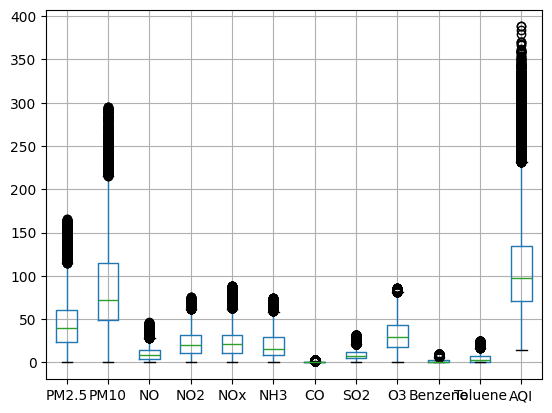

In [78]:
df_final.boxplot()

In [79]:
# % rows removed
(df.shape[0] - df_final.shape[0]) / df.shape[0] * 100


40.357772553629154

In [81]:
df_final.shape

(16237, 14)

In [107]:
X,y=df_final.drop(columns=["AQI_Bucket",'AQI']),df_final['AQI']

# **3.Encoding of Variables**

In [103]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


In [108]:
X['City']=le.fit_transform(X['City'])


In [109]:
X

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene
1,0,73.24,141.54,0.97,15.69,16.46,26.64,0.97,24.55,34.06,3.680000,5.500000
3,0,73.24,141.54,1.70,18.48,17.97,26.64,1.70,18.59,36.08,4.430000,10.140000
14,0,73.24,141.54,0.60,16.96,16.60,26.64,0.60,28.89,47.63,0.140000,0.040000
34,0,80.65,141.54,2.37,22.83,24.00,26.64,2.37,25.73,47.30,0.000000,0.000000
142,0,38.88,141.54,2.18,16.28,17.74,26.64,2.18,26.40,12.47,3.000000,6.960000
...,...,...,...,...,...,...,...,...,...,...,...,...
29526,24,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.240000,12.070000
29527,24,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.740000,2.210000
29528,24,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.010000,0.010000
29529,24,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.000000,0.000000


In [245]:
import pandas as pd

# Assuming your final cleaned dataset is named `cleaned_df`
X.to_csv('cleaned_X.csv', index=False)
y.to_csv('cleaned_y.csv', index=False)


# **Feature Selection**

In [114]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.feature_selection import SelectKBest, mutual_info_classif,mutual_info_regression
selector=SelectKBest(mutual_info_classif, k=6)
X_new = selector.fit_transform(X, y)
X_new

# Get scores and selected feature names
scores = selector.scores_
selected_features = X.columns[selector.get_support()]

# Create DataFrame of feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': scores
}).sort_values(by='Mutual_Information', ascending=False)

print(feature_importance)
print("\nSelected Features:", list(selected_features))

    Feature  Mutual_Information
1     PM2.5            0.788761
2      PM10            0.641611
0      City            0.233127
7        CO            0.206679
6       NH3            0.176625
4       NO2            0.166238
9        O3            0.157805
5       NOx            0.136853
3        NO            0.123611
11  Toluene            0.099072
10  Benzene            0.091301
8       SO2            0.066526

Selected Features: ['City', 'PM2.5', 'PM10', 'NO2', 'NH3', 'CO']


In [120]:
x_1=X[selected_features]
x_1


,City,PM2.5,PM10,NO2,NH3,CO
1,0,73.24,141.54,15.69,26.64,0.97
3,0,73.24,141.54,18.48,26.64,1.70
14,0,73.24,141.54,16.96,26.64,0.60
34,0,80.65,141.54,22.83,26.64,2.37
142,0,38.88,141.54,16.28,26.64,2.18
...,...,...,...,...,...,...
29526,24,15.02,50.94,25.06,12.47,0.47
29527,24,24.38,74.09,26.06,11.99,0.52
29528,24,22.91,65.73,29.53,10.71,0.48
29529,24,16.64,49.97,29.26,10.03,0.52


In [210]:
from sklearn.model_selection import train_test_split
#here only top6 parameters are used and X1 is denoted it by
X_train,X_test,y_train,y_test=train_test_split(x_1,y,test_size=0.2)
#for every_feature utilisation
#X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)


# **Scaling of Variables**

In [211]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [212]:
corr_matrix=pd.concat([x_1,y],axis=1).corr()
corr_matrix

,City,PM2.5,PM10,NO2,NH3,CO,AQI
City,1.000000,0.049369,-0.000833,0.038405,-0.218675,0.150788,0.076176
PM2.5,0.049369,1.000000,0.614253,0.405370,0.352950,0.274056,0.870614
PM10,-0.000833,0.614253,1.000000,0.394697,0.298038,0.176482,0.633243
NO2,0.038405,0.405370,0.394697,1.000000,0.206149,0.115817,0.393616
NH3,-0.218675,0.352950,0.298038,0.206149,1.000000,0.092435,0.325788
CO,0.150788,0.274056,0.176482,0.115817,0.092435,1.000000,0.349988
AQI,0.076176,0.870614,0.633243,0.393616,0.325788,0.349988,1.000000


In [213]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [214]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**Ml techniques**
| Technique                                  | Description                                      | Example Algorithm                   |
| ------------------------------------------ | ------------------------------------------------ | ----------------------------------- |
| **Linear Regression**                      | Fits a straight line to predict continuous value | `LinearRegression()`                |
| **Polynomial Regression**                  | Captures nonlinear patterns                      | `PolynomialFeatures`                |
| **Ridge/Lasso Regression**                 | Adds regularization to reduce overfitting        | `Ridge`, `Lasso`                    |
| **SVR (Support Vector Regression)**        | Uses kernel-based learning                       | `SVR()`                             |
| **Decision Tree Regression**               | Splits data into rules                           | `DecisionTreeRegressor()`           |
| **Random Forest Regression**               | Ensemble of multiple trees                       | `RandomForestRegressor()`           |
| **Gradient Boosting / XGBoost / LightGBM** | Sequential tree-based boosting                   | `XGBRegressor()`, `LGBMRegressor()` |



# **Support vector regression**

In [215]:
from sklearn.svm import SVR

In [216]:
sv=SVR()

In [217]:
sv=sv.fit(X_train,y_train)

In [218]:
y_pred= sv.predict(X_test)

In [219]:
from sklearn.metrics import r2_score,root_mean_squared_error

In [220]:
r2=r2_score(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

In [221]:
r2

0.7843427077418297

In [222]:
rmse

28.723794656492494

In [223]:
r_eror=root_mean_squared_error(y_train,sv.predict(X_train))

In [224]:
r_eror

27.75025424089859

In [225]:
# Importing the required libraries
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [226]:
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import uniform

# SVR model
svr = SVR()

# Parameter distribution
param_dist = {
    'C': uniform(0.1, 10),            # Try values between 0.1 and 100
    'epsilon': uniform(0.01, 1),       # Try values between 0.01 and 1
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_dist,
    n_iter=10,                      # Try 10 random combinations
    cv=3,                           # 3-fold cross-validation
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit to training data
random_search.fit(X_train, y_train)

# Best results
print("Best Parameters:", random_search.best_params_)
print("Best CV Score (neg MSE):", random_search.best_score_)

# Evaluate on test set
best_svr = random_search.best_estimator_
y_pred = best_svr.predict(X_test)

# Metrics
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² Score:", r2_score(y_test, y_pred))


In [227]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Boosting Techniques**

| Algorithm    | Speed | Handles Categorical | Regularization | Overfitting Control | Use Case                  |
| ------------ | ----- | ------------------- | -------------- | ------------------- | ------------------------- |
| **AdaBoost** | ⚡     | ❌                   | ❌              | Medium              | Simple datasets           |
| **GBM**      | ⚡⚡    | ❌                   | ❌              | Medium              | Generic boosting          |
| **XGBoost**  | ⚡⚡⚡   | ❌                   | ✅              | High                | Large tabular data        |
| **LightGBM** | ⚡⚡⚡⚡  | ✅                   | ✅              | High                | Large-scale data          |
| **CatBoost** | ⚡⚡⚡   | ✅                   | ✅              | Very High           | Mixed categorical/numeric |


# **Pipleline for the best model**

In [228]:
# 📦 Import Libraries
# ============================================
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [229]:
# External Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
!pip install kagglehub catboost

In [230]:
# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [231]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    return {"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae}


In [232]:
# 🚀 Model Definitions (Boosting + Others)
# ============================================
models = [
    ("AdaBoost", AdaBoostRegressor(n_estimators=100, learning_rate=0.1)),
    ("GradientBoosting", GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)),
    ("XGBoost", XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)),
    ("LightGBM", LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=42)),
    ("CatBoost", CatBoostRegressor(iterations=200, learning_rate=0.1, depth=6, verbose=0, random_seed=42)),
    ("RandomForest", RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)),
    ("LinearRegression", LinearRegression()),
    ("LogisticRegression", LogisticRegression(max_iter=1000)),  # not ideal for regression, but for comparison
    ("NaiveBayes", GaussianNB())
]

In [233]:
# 🧠 Deep Learning Model
# ============================================
def build_dl_model(input_dim):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

In [234]:
dl_model = build_dl_model(X_train.shape[1])
dl_model.fit(X_train, y_train, validation_split=0.1, epochs=50, batch_size=32, verbose=0)
dl_preds = dl_model.predict(X_test).ravel()
dl_results = {
    "Model": "DeepLearning (MLP)",
    "R2": r2_score(y_test, dl_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, dl_preds)),
    "MAE": mean_absolute_error(y_test, dl_preds)
}


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [235]:
# 🧮 Train and Evaluate All Models
# ============================================
results = []
for name, model in models:
    try:
        # scale-based models benefit from pipeline
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        res = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
        results.append(res)
    except Exception as e:
        print(f"⚠️ {name} failed: {e}")

results.append(dl_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001633 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2828
[LightGBM] [Info] Number of data points in the train set: 12989, number of used features: 12
[LightGBM] [Info] Start training from score 113.756486


In [236]:

# ============================================
# 📊 Compile and Display Results
# ============================================
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\n🔍 Model Performance Comparison:")
print(results_df)



🔍 Model Performance Comparison:
                Model        R2       RMSE        MAE
2             XGBoost  0.852151  23.783153  14.796806
3            LightGBM  0.851896  23.803653  14.356342
4            CatBoost  0.848742  24.055750  14.787769
1    GradientBoosting  0.843653  24.457105  15.280823
5        RandomForest  0.837060  24.967443  15.505572
6    LinearRegression  0.775507  29.306302  20.208772
9  DeepLearning (MLP)  0.750855  30.873476  20.052426
0            AdaBoost  0.731503  32.050085  23.627147
7  LogisticRegression  0.670599  35.499497  22.054187
8          NaiveBayes  0.450120  45.866302  25.904865


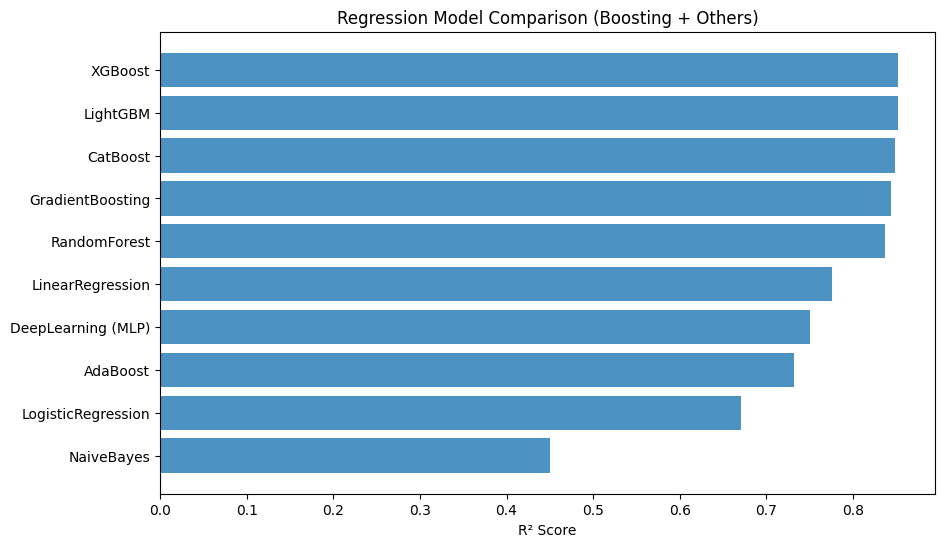

In [237]:
# ============================================
# 📈 Visualize Results
# ============================================
plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["R2"], alpha=0.8)
plt.xlabel("R² Score")
plt.title("Regression Model Comparison (Boosting + Others)")
plt.gca().invert_yaxis()
plt.show()

 1.With **6 features** only
 Xgboosta,LightGBM,Gboosting are best

 2.with **all features** xGBBOST IS AT THE TOP

**Hyperparmeter tunning** for the XGBOOST

In [238]:
# ============================================
# 📦 Import Dependencies
# ============================================
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

In [239]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [240]:
# ============================================
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.5, 1, 2],
    'min_child_weight': [1, 3, 5, 7, 10],
    'reg_alpha': [0, 0.1, 0.5, 1, 2],
    'reg_lambda': [0.5, 1, 2, 3]
}


In [241]:
# ============================================
# 🔍 RandomizedSearchCV Setup
# ============================================
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,              # number of parameter combinations to try
    scoring='r2',           # metric to optimize
    cv=3,                   # 3-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)


In [242]:
# 🧩 Fit the Model
# ============================================
random_search.fit(X_train, y_train)

# ============================================
# 🏆 Best Parameters
# ============================================
print("✅ Best Parameters Found:")
print(random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
✅ Best Parameters Found:
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


In [243]:
# 📊 Evaluate on Test Data
# ============================================
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\nModel Performance on Test Data:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


Model Performance on Test Data:
R² Score: 0.8559
RMSE: 23.4776
MAE: 14.1010


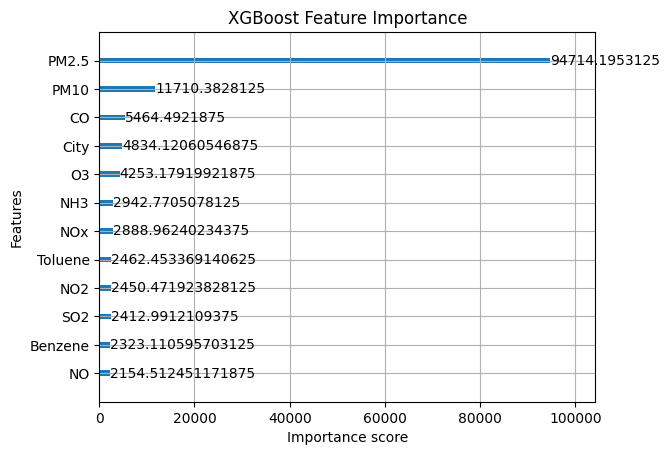

In [250]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(best_xgb, importance_type='gain')
plt.title("XGBoost Feature Importance")
plt.show()


In [246]:
import joblib

# Save model
joblib.dump(best_xgb, 'best_xgboost_model.pkl')

# Load model later
loaded_model = joblib.load('best_xgboost_model.pkl')

# Test loaded model
y_pred_loaded = loaded_model.predict(X_test)


# **Conclusion**
**The analysis revealed that particulate matter concentrations (PM2.5 and PM10) are the dominant contributors to AQI** levels across Indian cities, followed by CO, NO₂, and O₃. According to the feature importance chart, **PM2.5 has the highest predictive influence** — indicating its critical role in determining overall air quality.

**The trained XGBoost regression model achieved a high R² score, demonstrating strong predictive capability for estimating AQI based on pollutant data**. The model can be effectively used by environmental authorities and policymakers for:

Forecasting air pollution trends,

Identifying high-risk pollution sources, and

Implementing early warning systems in highly polluted urban areas.

In conclusion, machine learning provides a powerful tool for real-time AQI forecasting, enabling data-driven environmental management and public health protection. However, the model’s performance could be further enhanced by incorporating meteorological variables (e.g., wind speed, humidity, temperature) and temporal features (seasonal and hourly trends) to capture the complex dynamics of air pollution.